<a href="https://colab.research.google.com/github/SrimaniGabrielle/Myprojects/blob/main/RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install sentence-transformers
!pip install faiss-cpu
!pip install transformers
!pip install nltk
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 71.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import faiss
import nltk
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from transformers import pipeline
from nltk.tokenize import sent_tokenize

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [5]:
df = pd.read_csv("climate-fever.csv")

df.head()

,claim_id,claim,claim_label,evidences/0/evidence_id,evidences/0/evidence_label,evidences/0/article,evidences/0/evidence,evidences/0/entropy,evidences/0/votes/0,evidences/0/votes/1,...,evidences/4/evidence_id,evidences/4/evidence_label,evidences/4/article,evidences/4/evidence,evidences/4/entropy,evidences/4/votes/0,evidences/4/votes/1,evidences/4/votes/2,evidences/4/votes/3,evidences/4/votes/4
0,0,Global warming is driving polar bears toward e...,SUPPORTS,Extinction risk from global warming:170,NOT_ENOUGH_INFO,Extinction risk from global warming,"""Recent Research Shows Human Activity Driving ...",0.693147,SUPPORTS,NOT_ENOUGH_INFO,...,Polar bear:1328,NOT_ENOUGH_INFO,Polar bear,"""Bear hunting caught in global warming debate"".",0.693147,SUPPORTS,NOT_ENOUGH_INFO,NaN,NaN,NaN
1,5,The sun has gone into ‘lockdown’ which could c...,SUPPORTS,Famine:386,SUPPORTS,Famine,The current consensus of the scientific commun...,0.000000,SUPPORTS,SUPPORTS,...,Winter:5,NOT_ENOUGH_INFO,Winter,"In many regions, winter is associated with sno...",0.693147,REFUTES,NOT_ENOUGH_INFO,NaN,NaN,NaN
2,6,The polar bear population has been growing.,REFUTES,Polar bear:1332,NOT_ENOUGH_INFO,Polar bear,"""Ask the experts: Are polar bear populations i...",0.693147,NOT_ENOUGH_INFO,REFUTES,...,Polar bear:61,REFUTES,Polar bear,Of the 19 recognized polar bear subpopulations...,0.000000,REFUTES,REFUTES,NaN,NaN,NaN
3,9,Ironic' study finds more CO2 has slightly cool...,REFUTES,Atmosphere of Mars:131,NOT_ENOUGH_INFO,Atmosphere of Mars,CO2 in the mesosphere acts as a cooling agent ...,0.693147,NOT_ENOUGH_INFO,SUPPORTS,...,Carbon dioxide:191,NOT_ENOUGH_INFO,Carbon dioxide,"Less energy reaches the upper atmosphere, whic...",0.000000,NOT_ENOUGH_INFO,NOT_ENOUGH_INFO,NaN,NaN,NaN
4,10,Human additions of CO2 are in the margin of er...,REFUTES,Carbon dioxide in Earth's atmosphere:140,NOT_ENOUGH_INFO,Carbon dioxide in Earth's atmosphere,While CO 2 absorption and release is always ha...,0.693147,NOT_ENOUGH_INFO,REFUTES,...,Sea:226,REFUTES,Sea,"More recently, anthropogenic activities have s...",0.000000,REFUTES,REFUTES,NaN,NaN,NaN


In [11]:
evidence_columns = [
    'evidences/0/evidence',
    'evidences/1/evidence',
    'evidences/2/evidence',
    'evidences/3/evidence',
    'evidences/4/evidence'
]

documents = []

for col in evidence_columns:
    documents.extend(df[col].dropna().tolist())

print("Total evidence sentences:", len(documents))

Total evidence sentences: 7675


In [10]:
print(df.columns)

Index(['claim_id', 'claim', 'claim_label', 'evidences/0/evidence_id',
       'evidences/0/evidence_label', 'evidences/0/article',
       'evidences/0/evidence', 'evidences/0/entropy', 'evidences/0/votes/0',
       'evidences/0/votes/1', 'evidences/0/votes/2', 'evidences/0/votes/3',
       'evidences/0/votes/4', 'evidences/1/evidence_id',
       'evidences/1/evidence_label', 'evidences/1/article',
       'evidences/1/evidence', 'evidences/1/entropy', 'evidences/1/votes/0',
       'evidences/1/votes/1', 'evidences/1/votes/2', 'evidences/1/votes/3',
       'evidences/1/votes/4', 'evidences/2/evidence_id',
       'evidences/2/evidence_label', 'evidences/2/article',
       'evidences/2/evidence', 'evidences/2/entropy', 'evidences/2/votes/0',
       'evidences/2/votes/1', 'evidences/2/votes/2', 'evidences/2/votes/3',
       'evidences/2/votes/4', 'evidences/3/evidence_id',
       'evidences/3/evidence_label', 'evidences/3/article',
       'evidences/3/evidence', 'evidences/3/entropy', 'evide

In [12]:
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
doc_embeddings = embedding_model.encode(documents)

In [15]:
dimension = doc_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(doc_embeddings))

print("Vector database created")

Vector database created


In [16]:
generator = pipeline("text-generation", model="gpt2")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [17]:
def ask_llm(question):

    response = generator(
        question,
        max_length=60,
        num_return_sequences=1
    )

    return response[0]['generated_text']

In [18]:
def retrieve_evidence(query, k=2):

    query_embedding = embedding_model.encode([query])

    distances, indices = index.search(
        np.array(query_embedding),
        k
    )

    evidence = [documents[i] for i in indices[0]]

    return evidence

In [19]:
def extract_claims(answer):

    claims = sent_tokenize(answer)

    return claims

In [20]:
def verify_claims(answer):

    claims = extract_claims(answer)

    results = []

    for claim in claims:

        evidence = retrieve_evidence(claim)

        claim_emb = embedding_model.encode([claim])
        evidence_emb = embedding_model.encode(evidence)

        similarity = np.dot(claim_emb, evidence_emb.T)

        score = float(np.max(similarity))

        results.append({
            "claim": claim,
            "evidence": evidence[0],
            "score": score
        })

    return results

In [21]:
def compute_final_score(results):

    scores = [r['score'] for r in results]

    return sum(scores) / len(scores)

In [22]:
def classify_risk(score):

    if score > 0.8:
        return "LOW Hallucination Risk"

    elif score > 0.5:
        return "MEDIUM Hallucination Risk"

    else:
        return "HIGH Hallucination Risk"

In [23]:
def plot_scores(results):

    claims = [r['claim'] for r in results]
    scores = [r['score'] for r in results]

    plt.figure(figsize=(8,4))

    plt.barh(range(len(scores)), scores)

    plt.yticks(range(len(scores)), claims)

    plt.xlabel("Similarity Score")

    plt.title("Claim Verification Scores")

    plt.show()

In [24]:
question = "Is climate change caused by human activity?"

answer = ask_llm(question)

print("Question:", question)
print("\nLLM Answer:\n", answer)

Passing `generation_config` together with generation-related arguments=({'max_length', 'num_return_sequences'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: Is climate change caused by human activity?

LLM Answer:
 Is climate change caused by human activity?

The debate over whether the Arctic is warming is not limited to climate change. As the Arctic ice sheet continues to melt, it is likely that sea level will rise to around 20 feet (6 meters) by the end of the century. By 2050, the Arctic sea level will rise to about 1,800 feet (1,300 meters) above sea level, according to the Intergovernmental Panel on Climate Change.

Scientists have long known that the Arctic is warming rapidly, with an average of 1 degree C in the Arctic in 2015.

Some Arctic scientists believe that the Arctic is losing sea-level rise because of the melting of the ice sheet. Others say that the Arctic is losing sea-level rise due to a combination of factors.

According to Grist, global warming is increasing the Arctic's ice sheet thickness by 1,000 feet (1,200 meters) and melting in the Arctic Ocean by 1,000 feet (1,500 meters).

Scientists have long known 

In [26]:
import nltk
nltk.download('punkt_tab')

results = verify_claims(answer)

for r in results:

    print("\nClaim:", r["claim"])
    print("Evidence:", r["evidence"])
    print("Score:", r["score"])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Claim: Is climate change caused by human activity?
Evidence: Anthropogenic climate change is caused by human activity, as opposed to changes in climate that may have resulted as part of Earth's natural processes.
Score: 0.8229722380638123

Claim: The debate over whether the Arctic is warming is not limited to climate change.
Evidence: The Arctic is especially vulnerable to the effects of any climate change, as has become apparent with the reduction of sea ice in recent years.
Score: 0.6468797326087952

Claim: As the Arctic ice sheet continues to melt, it is likely that sea level will rise to around 20 feet (6 meters) by the end of the century.
Evidence: Estimates on future contribution to sea level rise from Greenland range from 0.3 to 3 metres (1 to 10 ft), for the year 2100.
Score: 0.786806583404541

Claim: By 2050, the Arctic sea level will rise to about 1,800 feet (1,300 meters) above sea level, according to the Intergovernmental Panel on Climate Change.
Evidence: According to the

In [27]:
final_score = compute_final_score(results)

risk = classify_risk(final_score)

print("\nFinal Hallucination Score:", final_score)
print("Hallucination Risk:", risk)


Final Hallucination Score: 0.7276603416963057
Hallucination Risk: MEDIUM Hallucination Risk


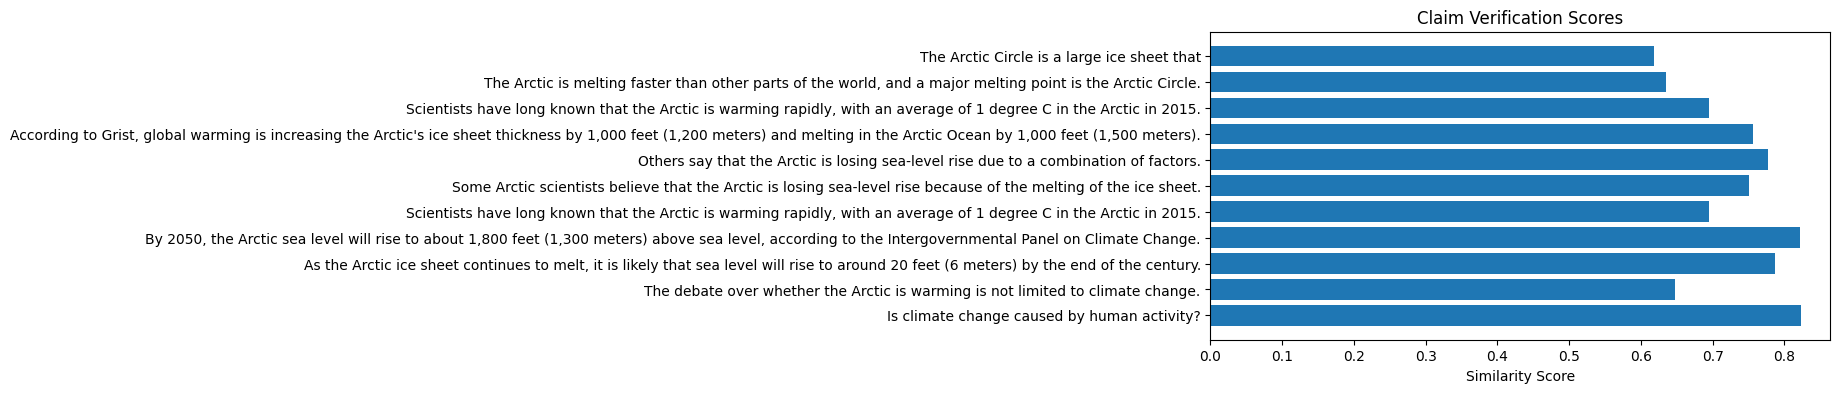

In [28]:
plot_scores(results)